### Из семинара

In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import numpy
import pandas
import scipy.sparse
import sklearn.metrics
import sklearn.preprocessing
import sklearn.model_selection

In [4]:
all_data = pandas.read_csv("estonia-passenger-list.csv")
anonymized_data = all_data.drop(["Firstname", "Lastname", "PassengerId"], axis=1)
y = anonymized_data["Survived"]

In [5]:
data_train, data_test, y_train, y_test = sklearn.model_selection.train_test_split(
    anonymized_data.drop(["Survived"], axis=1),
    anonymized_data["Survived"],
    test_size=0.3,
    random_state=1337,
    stratify=anonymized_data["Survived"]
)

In [6]:
def prepare_features_for_logreg(data: pandas.DataFrame, cat_encoder=None, real_scaler=None):
    cat_columns = ["Country", "Sex", "Category"]
    real_columns = ["Age"]

    # categorical features
    if cat_encoder is None:
        ohe = sklearn.preprocessing.OneHotEncoder(handle_unknown="ignore", drop = 'first')
        ohe.fit(data[cat_columns])
    else:
        ohe = cat_encoder
    X_cat = ohe.transform(data[cat_columns])
    cat_fnames = ohe.get_feature_names_out(cat_columns)

    # real-valued features
    if real_scaler is None:
        stsc = sklearn.preprocessing.StandardScaler()
        stsc.fit(data[real_columns])
    else:
        stsc = real_scaler
    X_real = stsc.transform(data[real_columns])
    feature_matrix = scipy.sparse.hstack([X_cat, X_real])

    return feature_matrix, list(cat_fnames) + real_columns, ohe, stsc

X_train_sparse, fnames_sparse, encoder_sparse, scaler = prepare_features_for_logreg(data_train)
X_test_sparse, _, _, _ = prepare_features_for_logreg(data_test, encoder_sparse, scaler)

X_train_sparse.shape, X_test_sparse.shape

d:\Programs\Programming\Python\lib\site-packages\sklearn\preprocessing\_encoders.py:242: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


((692, 17), (297, 17))

# Задача 5. Паром (1 балл).

Получите accuracy > 0.89 на тестовом датасете. Можно пользоваться любым классификатором **из sklearn**. Ансамблями пользоваться можно.

### XtreemeGradientBoosting и нейронные сети запрещены.

### ч.1

In [7]:
import sklearn.dummy
import sklearn.metrics

rf = sklearn.dummy.DummyClassifier(strategy='most_frequent')
rf.fit(X_train_sparse, y_train)
sklearn.metrics.accuracy_score(y_test, rf.predict(X_test_sparse))

0.8619528619528619

In [8]:
import sklearn.metrics
import sklearn.ensemble
import sklearn.neighbors
import sklearn.linear_model

rf = sklearn.ensemble.StackingClassifier([
    ('rf', sklearn.ensemble.RandomForestClassifier(n_estimators = 100, random_state = 42, max_features = None, max_samples=0.3)),
    ('et', sklearn.ensemble.ExtraTreesClassifier(n_estimators = 100, random_state=42, max_features = None)),
    ('knn', sklearn.neighbors.KNeighborsClassifier(n_neighbors=5)),
    ('lr', sklearn.linear_model.LogisticRegression(C = 0.1)),
    ('gb', sklearn.ensemble.HistGradientBoostingClassifier(early_stopping=False))
], sklearn.linear_model.LogisticRegression())

rf.fit(X_train_sparse.toarray(), y_train)
sklearn.metrics.accuracy_score(y_test, rf.predict(X_test_sparse.toarray()))

0.8619528619528619

In [11]:
from sklearn.model_selection import GridSearchCV

clf = GridSearchCV(
    rf,
    {
        'rf__max_depth': [ None, 2 ],
        'rf__class_weight': [ None, 'balanced' ],
        'rf__n_estimators': [50, 100, 250],
        'et__max_depth': [ None, 2 ],
        'et__n_estimators': [50, 100, 250],
        'et__class_weight': [ None, 'balanced' ],
        'knn__n_neighbors': [ 3, 5, 7 ],
        'lr__C': [ 0.01, 0.25, 0.75 ],
        'gb__class_weight': [ None, 'balanced' ],
        'gb__validation_fraction': [ 0, 0.1 ],
        'gb__max_iter': [50, 100, 250],
        'final_estimator__C': [ 0.01, 0.25, 0.75 ],
        'final_estimator__class_weight': [ None, 'balanced' ]
    },
    scoring="accuracy",
    verbose=4,
    cv=3,
    n_jobs=-1
)

clf.fit(X_train_sparse.toarray(), y_train)

Fitting 3 folds for each of 93312 candidates, totalling 279936 fits


100%|██████████| 279936/279936 [6:39:19<00:00, 11.68it/s]  
d:\Programs\Programming\Python\lib\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
139968 fits failed out of a total of 279936.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
139968 fits failed with the following error:
Traceback (most recent call last):
  File "d:\Programs\Programming\Python\lib\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\Programs\Programming\Python\lib\site-packages\sklearn\ensemble\_stacking.py", line 672, in fit
    return super().fit(X, y_encoded, sample_weight)
  File "d:\Programs\Programming\Python\lib\site-packages\sklearn\bas

GridSearchCV(cv=3,
             estimator=StackingClassifier(estimators=[('rf',
                                                       RandomForestClassifier(max_features=None,
                                                                              max_samples=0.3,
                                                                              random_state=42)),
                                                      ('et',
                                                       ExtraTreesClassifier(max_features=None,
                                                                            random_state=42)),
                                                      ('knn',
                                                       KNeighborsClassifier()),
                                                      ('lr',
                                                       LogisticRegression(C=0.1)),
                                                      ('gb',
                                                       HistGradientBoostingClassifier(early_stopping=False))],
                                          final_estimator=Logist...
                         'final_estimator__C': [0.01, 0.25, 0.75],
                         'final_estimator__class_weight': [None, 'balanced'],
                         'gb__class_weight': [None, 'balanced'],
                         'gb__max_iter': [50, 100, 250],
                         'gb__validation_fraction': [0, 0.1],
                         'knn__n_neighbors': [3, 5, 7],
                         'lr__C': [0.01, 0.25, 0.75],
                         'rf__class_weight': [None, 'balanced'],
                         'rf__max_depth': [None, 2],
                         'rf__n_estimators': [50, 100, 250]},
             scoring='accuracy', verbose=4)

In [13]:
clf.best_params_

{'et__class_weight': None,
 'et__max_depth': None,
 'et__n_estimators': 50,
 'final_estimator__C': 0.01,
 'final_estimator__class_weight': None,
 'gb__class_weight': None,
 'gb__max_iter': 50,
 'gb__validation_fraction': 0.1,
 'knn__n_neighbors': 3,
 'lr__C': 0.01,
 'rf__class_weight': None,
 'rf__max_depth': None,
 'rf__n_estimators': 50}

In [14]:
sklearn.metrics.accuracy_score(y_test, clf.predict(X_test_sparse.toarray()))

0.8619528619528619

Данные слишком плохие, чтобы уверенно получить хотя бы что-то лучшее константного прогноза :(

### ч.2

In [357]:
data = X_train_sparse.toarray()
labels = 1 - y_train.to_numpy()

test_data = X_test_sparse.toarray()
test_labels = 1 - y_test.to_numpy()

def make_train():
    # Default bootstraping did not work with such a huge class imbalance. So I decided to make my own.
    idx0 = numpy.random.choice(numpy.where(labels == 1)[0], size = 100)
    idx1 = numpy.random.choice(numpy.where(labels == 0)[0], size = 100)
    idx = numpy.array([*idx0, *idx1])
    return data[idx], labels[idx]

In [358]:
import tqdm
import sklearn.ensemble
import sklearn.linear_model

numpy.random.seed(42)
rfs = [
    *[
        sklearn.ensemble.RandomForestClassifier(n_estimators = 100, random_state = 42, max_features = None)
        for _ in range(200)
    ],
    *[
        sklearn.ensemble.HistGradientBoostingClassifier(early_stopping=False)
        for _ in range(200)
    ],
    *[
        sklearn.ensemble.ExtraTreesClassifier(n_estimators = 100, max_features = None)
        for _ in range(200)
    ],
    *[
        sklearn.ensemble.BaggingClassifier(n_estimators = 100)
        for _ in range(200)
    ],
    *[
        sklearn.linear_model.LogisticRegression(max_iter = 1000)
        for _ in range(200)
    ]
]
for rf in tqdm.tqdm(rfs):
    # Train a lot of models on random subsets because we can
    rf.fit(*make_train())

# Count predictions. Basically voting.
predicts = [ { 0: 0, 1: 0 } for _ in range(len(test_labels)) ]
for rf in tqdm.tqdm(rfs):
    for i, predict in enumerate(rf.predict_proba(test_data)):
        if predict[0] == predict[1]:
            continue
        if predict[0] > predict[1]:
            predicts[i][0] += 1
        if predict[0] < predict[1]:
            predicts[i][1] += 1

100%|██████████| 1000/1000 [00:02<00:00, 337.22it/s]


In [359]:
# Train one decision stump on full dataset. If the stump is completely indecisive, we might want to intervene the voting
# (this means we probably have multiple contradicting records in the dataset with same features but different targets)
# Experimentally, this proved to give the required accuracy.
rf = sklearn.ensemble.RandomForestClassifier(n_estimators = 1, max_features = None, random_state = 42)
rf.fit(data, labels)
rf_preds = rf.predict_proba(test_data)

In [360]:
preds = []
for index, item in enumerate(predicts):
    if item[1] > 97: # Voting with preference to the minority class.
        if rf_preds[index][0] == rf_preds[index][1]:
            # If the stump is indecisive, switch vote (expert decision).
            preds.append(0)
            continue
        preds.append(1)
        continue
    if rf_preds[index][0] == rf_preds[index][1]:
        # If the stump is indecisive, switch vote (expert decision).
        preds.append(1)
        continue
    preds.append(0)
print(sklearn.metrics.accuracy_score(test_labels, preds))

0.8922558922558923


# Задача 6. Линрег (1 балл)

Допустим, у вас есть два множества **A** и **B** точек на плоскости. Линейная регрессия на плоскости -- это
просто прямая, ее можно представить как функцию $ y = ax + b$.

Линейная регрессия, обученная на множестве **А**, имеет коэффициент **$a > 0$**. То же самое верно и для линейной регрессии, обученной на множестве **B**. Правда ли, что если обучить линейную регрессию на множестве $A \cup B$, то у полученной прямой коэффициент **a** будет больше 0?

Если да -  докажите, если нет - постройте контрпример.

In [405]:
# Ответ: нет

A_x = numpy.array([ 0, 1 ])
A_y = numpy.array([ 0, 1 ])

B_x = numpy.array([ 10, 11 ])
B_y = numpy.array([ -11, -10 ])

A: y = 1.0 * x + 0.0
B: y = 1.0000000000000533 * x + -21.000000000000853
Combined: y = -1.079207920792079 * x + 0.9356435643564349


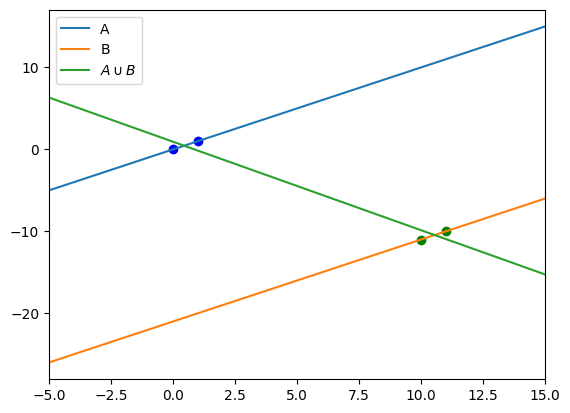

In [406]:
import matplotlib.pyplot as plt

def solve_linreg(x, y):
    x = numpy.array(x).reshape(-1, 1)
    x = numpy.concat([ x, numpy.ones_like(x) ], axis = 1)
    return numpy.linalg.inv(x.T @ x) @ x.T @ y # Exact, statistically best solution for fit linear regression

xlim = numpy.array([ -5, 15 ])
plt.xlim(*xlim)

plt.scatter(A_x, A_y, color = 'blue')
a, b = solve_linreg(A_x, A_y)
plt.plot(xlim, a * xlim + b, label = 'A')
print(f"A: y = {a} * x + {b}")

plt.scatter(B_x, B_y, color = 'green')
a, b = solve_linreg(B_x, B_y)
plt.plot(xlim, a * xlim + b, label = 'B')
print(f"B: y = {a} * x + {b}")

a, b = solve_linreg([ *A_x, *B_x ], [ *A_y, *B_y ])
plt.plot(xlim, a * xlim + b, label = '$A \cup B$')
print(f"Combined: y = {a} * x + {b}")

plt.legend()